In [2]:
import duckdb
import pandas as pd
import plotly.express as px

# Connect to DuckDB
con = duckdb.connect()

# Create SQL views
con.execute("CREATE VIEW dim_users AS SELECT * FROM 'C:/Users/uduok/git_folder/Saas_Lead_Conversion/data/raw/dim_users.csv'")
con.execute("CREATE VIEW fact_events AS SELECT * FROM 'C:/Users/uduok/git_folder/Saas_Lead_Conversion/data/raw/fact_events.csv'")
con.execute("CREATE VIEW fact_subs AS SELECT * FROM '../data/raw/fact_subs.csv'")

In [3]:
top_users = con.execute("""
    SELECT 
        user_id, 
        count(*) as event_count 
    FROM fact_events 
    GROUP BY 1 
    ORDER BY 2 DESC 
    LIMIT 5
""").df()

print("Connection Successful! Top Users by Event Volume:")
print(top_users)

Connection Successful! Top Users by Event Volume:
    user_id  event_count
0  4731fbf3           79
1  46da3991           79
2  bc312a64           79
3  684117bb           79
4  61fb70dd           79


In [4]:
# Activation & Feature Counts
con.execute("""
CREATE OR REPLACE TABLE int_user_behaviour_summary AS
SELECT 
    user_id,
    COUNT(*) FILTER (WHERE event_name = 'video_recorded') AS total_recordings,
    COUNT(*) FILTER (WHERE event_name = 'video_shared') AS total_shares,
    COUNT(*) FILTER (WHERE event_name = 'team_invited') AS total_invites,
    COUNT(*) FILTER (WHERE event_name = 'app_error') AS total_errors,
    MIN(timestamp) AS first_event_at,
    MAX(timestamp) AS last_event_at
FROM fact_events
GROUP BY 1;
""")

df_behaviour_summary = con.execute("SELECT * FROM int_user_behaviour_summary LIMIT 10").df()
display(df_behaviour_summary)

,user_id,total_recordings,total_shares,total_invites,total_errors,first_event_at,last_event_at
0,96d475d3,5,0,0,6,2025-01-02 05:37:26.243101,2025-01-07 16:12:27.299303
1,cda67b81,16,19,23,0,2025-01-10 00:52:40.900000,2025-01-22 08:18:05.261729
2,5e6f87ae,5,0,0,6,2025-01-16 03:05:08.427431,2025-01-27 17:33:32.116448
3,892a1eff,1,0,0,7,2025-01-19 00:13:55.519109,2025-01-22 20:11:16.925027
4,acd55ba8,3,0,0,0,2025-01-03 03:39:17.978694,2025-01-08 13:44:02.262444
5,d1703b1c,0,0,0,0,2025-01-20 18:32:19.344210,2025-01-20 18:32:19.344210
6,79fee4fa,4,0,0,10,2025-01-25 10:53:11.119752,2025-02-01 03:58:07.111935
7,301182c5,3,0,0,0,2025-01-22 08:28:56.955115,2025-01-28 05:47:16.140450
8,2e0adefc,15,14,22,0,2025-01-07 03:46:01.345974,2025-01-22 09:20:17.817529
9,4b98090c,6,13,13,0,2025-01-22 00:07:06.412399,2025-01-30 00:19:09.737252


In [5]:
# Time to Value (TTV)
con.execute ("""
CREATE OR REPLACE TABLE int_activation_metrics AS
WITH first_three_videos AS (
    SELECT 
        user_id, 
        timestamp AS aha_at,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp) as row_num
    FROM fact_events
    WHERE event_name = 'video_recorded'
)
SELECT 
    u.user_id,
    u.signup_date,
    a.aha_at,
    DATE_DIFF('day', u.signup_date, a.aha_at) AS days_to_aha,
    CASE WHEN a.aha_at IS NOT NULL THEN TRUE ELSE FALSE END AS is_activated
FROM dim_users u
LEFT JOIN first_three_videos a ON u.user_id = a.user_id AND a.row_num = 3;
""")

df_activation_metrics = con.execute("SELECT * FROM int_activation_metrics LIMIT 10").df()
display(df_activation_metrics)

,user_id,signup_date,aha_at,days_to_aha,is_activated
0,0b2a6ba5,2025-01-25,2025-01-26 21:55:37.777973,1,True
1,0cf67126,2025-01-05,2025-01-06 18:35:41.889758,1,True
2,128061ff,2025-01-17,2025-01-17 20:02:44.952797,0,True
3,13c54267,2025-01-11,2025-01-11 15:14:18.935648,0,True
4,18dd416f,2025-01-23,2025-01-23 21:05:44.562979,0,True
5,1a9a3057,2025-01-20,2025-01-21 19:46:05.204631,1,True
6,292f23f3,2025-01-24,2025-02-01 03:09:12.717948,8,True
7,2ec04ca7,2025-01-18,2025-01-18 09:17:59.982693,0,True
8,32888d73,2025-01-03,2025-01-09 14:25:36.620798,6,True
9,33ee7355,2025-01-10,2025-01-11 07:42:43.256723,1,True


In [6]:
# Weighted Intent Scoring
con.execute("""
CREATE OR REPLACE TABLE int_user_intent_scores AS
WITH behavioral_counts AS (
    SELECT 
        user_id,
        COUNT(*) FILTER (WHERE event_name = 'video_recorded') AS total_recordings,
        COUNT(*) FILTER (WHERE event_name = 'video_shared') AS total_shares,
        COUNT(*) FILTER (WHERE event_name = 'team_invited') AS total_invites,
        COUNT(*) FILTER (WHERE event_name = 'app_error') AS total_errors
    FROM fact_events
    GROUP BY 1
)
SELECT 
    user_id,
    -- The Weighting Logic:
    -- +10 for a recording (core value)
    -- +5 for a share (virality)
    -- +25 for an invite (expansion signal - the most valuable)
    -- -15 for an error (friction signal - reduces intent)
    (total_recordings * 10) + (total_shares * 5) + (total_invites * 25) - (total_errors * 15) AS intent_score,
    
    -- Assigning Tiers for the Sales/Growth teams
    CASE 
        WHEN (total_recordings * 10) + (total_shares * 5) + (total_invites * 25) - (total_errors * 15) >= 80 THEN 'High Intent'
        WHEN (total_recordings * 10) + (total_shares * 5) + (total_invites * 25) - (total_errors * 15) >= 40 THEN 'Medium Intent'
        ELSE 'Low Intent'
    END AS intent_tier
FROM behavioral_counts;
""")

df_intent_scores = con.execute("SELECT * FROM int_user_intent_scores ORDER BY intent_score DESC LIMIT 10").df()
display(df_intent_scores)

,user_id,intent_score,intent_tier
0,46da3991,1200,High Intent
1,5b8ba452,1180,High Intent
2,61fb70dd,1180,High Intent
3,684117bb,1170,High Intent
4,a5b66121,1120,High Intent
5,bc312a64,1120,High Intent
6,77ea6c1c,1105,High Intent
7,e5753f4b,1105,High Intent
8,da79b6aa,1100,High Intent
9,7b4a981f,1100,High Intent


In [22]:
# Friction & Recency (Health Score)
con.execute("""
CREATE OR REPLACE TABLE int_user_health AS
WITH user_activity AS (
    SELECT 
        user_id,
        MAX(timestamp) AS last_event_at,
        COUNT(*) FILTER (WHERE event_name = 'app_error') AS total_errors,
        DATE_DIFF('day', MAX(timestamp), CAST('2025-02-01' AS TIMESTAMP)) AS days_since_last_action,
        COUNT(*) AS total_events
    FROM fact_events
    GROUP BY 1
)
SELECT 
    u.user_id,
    a.total_errors,
    -- Calculate error density: errors relative to total activity
    ROUND((a.total_errors * 1.0) / NULLIF(a.total_events, 0), 3) AS friction_ratio,
    -- Recency: How many days since they last touched the app
    DATE_DIFF('day', a.last_event_at, CAST('2025-02-01' AS TIMESTAMP)) AS days_since_last_action,
    -- Health Logic
    CASE 
        WHEN DATE_DIFF('day', a.last_event_at, CAST('2025-02-01' AS TIMESTAMP)) > 7 THEN 'Inactive'
        WHEN (a.total_errors * 1.0) / NULLIF(a.total_events, 0) > 0.15 THEN 'Frustrated'
        ELSE 'Healthy'
    END AS health_segment
FROM dim_users u
LEFT JOIN user_activity a ON u.user_id = a.user_id;
""")

df_health = con.execute("SELECT * FROM int_user_health LIMIT 10").df()
display(df_health)

,user_id,total_errors,friction_ratio,days_since_last_action,health_segment
0,208faa8b,0,0.0,-2,Healthy
1,bc1338e3,0,0.0,16,Inactive
2,82d58c9b,0,0.0,14,Inactive
3,9d1cab17,0,0.0,20,Inactive
4,365b039f,0,0.0,22,Inactive
5,878de0d6,0,0.0,10,Inactive
6,c415baaf,0,0.0,24,Inactive
7,0bde3935,0,0.0,1,Healthy
8,1b59b3ff,0,0.0,17,Inactive
9,5d99dd66,0,0.0,14,Inactive


In [23]:
# The Master Table
con.execute("""
CREATE OR REPLACE TABLE fct_pql_master AS
SELECT 
    u.user_id,
    u.org_size,
    -- Activation Signal
    COALESCE(act.is_activated, FALSE) AS is_activated,
    act.days_to_aha,
    -- Intent Signal
    score.intent_score,
    score.intent_tier,
    -- Health Signal
    health.days_since_last_action,
    health.health_segment,
    -- Revenue Data
    s.plan_level,
    s.mrr
FROM dim_users u
LEFT JOIN int_activation_metrics act ON u.user_id = act.user_id
LEFT JOIN int_user_intent_scores score ON u.user_id = score.user_id
LEFT JOIN int_user_health health ON u.user_id = health.user_id
LEFT JOIN fact_subs s ON u.user_id = s.user_id;
""")

df_master_table_view = con.execute("""
    SELECT 
        user_id,
        org_size,
        intent_score,
        intent_tier,
        health_segment,
        days_since_last_action,
        mrr,
        plan_level
        FROM fct_pql_master
        ORDER BY mrr DESC, intent_score DESC
        LIMIT 50
""").df()

display(df_master_table_view)

,user_id,org_size,intent_score,intent_tier,health_segment,days_since_last_action,mrr,plan_level
0,77c056b0,Enterprise,1055,High Intent,Inactive,12,7039.04,Enterprise
1,bff19248,Enterprise,590,High Intent,Healthy,5,5404.76,Enterprise
2,cda67b81,Enterprise,830,High Intent,Inactive,10,4894.66,Enterprise
3,10a1fba9,Enterprise,935,High Intent,Healthy,-6,4725.11,Enterprise
4,b369b22a,Enterprise,555,High Intent,Healthy,-4,4455.23,Enterprise
5,2e0adefc,Enterprise,770,High Intent,Inactive,10,3910.90,Enterprise
6,5b8ba452,Enterprise,1180,High Intent,Healthy,6,3796.37,Enterprise
7,46da3991,Enterprise,1200,High Intent,Inactive,14,3264.29,Enterprise
8,1a581cb8,Enterprise,0,Low Intent,Inactive,21,3069.34,Enterprise
9,c67a038b,Enterprise,10,Low Intent,Inactive,29,2874.02,Enterprise


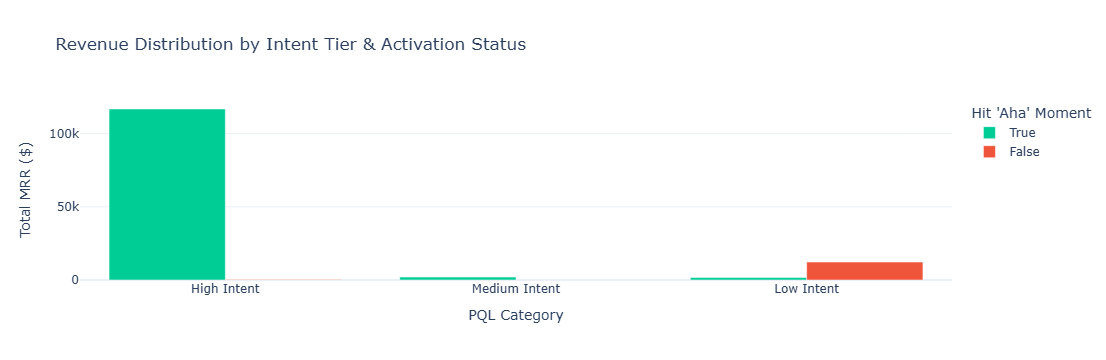

In [24]:
# Aggregate the data for the chart
df_plot = con.execute("""
    SELECT 
        intent_tier, 
        is_activated,
        SUM(mrr) as total_revenue,
        COUNT(user_id) as user_count
    FROM fct_pql_master
    GROUP BY 1, 2
    ORDER BY total_revenue DESC
""").df()

# Create an interactive Bar Chart
fig = px.bar(
    df_plot, 
    x="intent_tier", 
    y="total_revenue", 
    color="is_activated",
    title="Revenue Distribution by Intent Tier & Activation Status",
    labels={"total_revenue": "Total MRR ($)", "intent_tier": "PQL Category", "is_activated": "Hit 'Aha' Moment"},
    barmode="group",
    template="plotly_white",
    color_discrete_map={True: "#00CC96", False: "#EF553B"} # Green for activated, Red for not
)

fig.show()

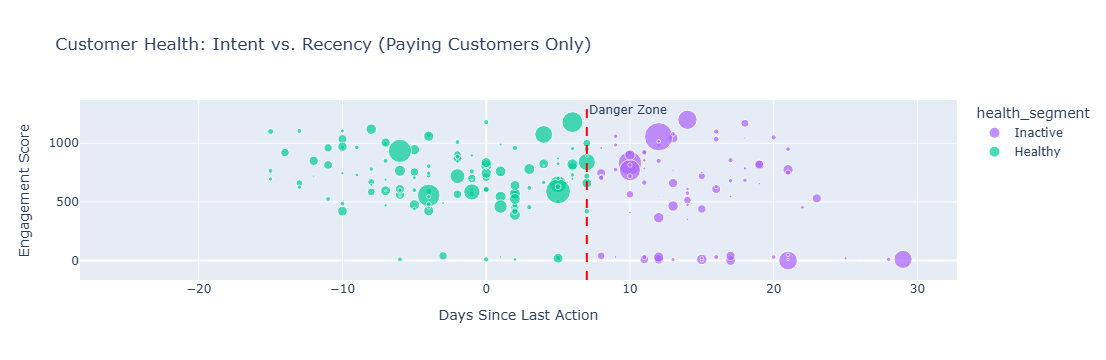

In [25]:
# Churn Risk: Intent Score vs. Recency
df_churn = con.execute("""
    SELECT 
        intent_score, 
        days_since_last_action, 
        mrr,
        org_size,
        health_segment
    FROM fct_pql_master
    WHERE mrr > 0  -- Focus only on paying customers
""").df()

fig = px.scatter(
    df_churn, 
    x="days_since_last_action", 
    y="intent_score", 
    size="mrr", 
    color="health_segment",
    hover_name="org_size",
    title="Customer Health: Intent vs. Recency (Paying Customers Only)",
    labels={"days_since_last_action": "Days Since Last Action", "intent_score": "Engagement Score"},
    color_discrete_map={"Healthy": "#00CC96", "Churn Risk - Inactive": "#EF553B", "Churn Risk - Frustrated": "#AB63FA"}
)

# Add a vertical line at 7 days to show the "Danger Zone"
fig.add_vline(x=7, line_dash="dash", line_color="red", annotation_text="Danger Zone")

fig.show()

In [26]:
# Create the "Sync File" for HubSpot
hubspot_sync_df = con.execute("""
    SELECT 
        user_id,
        org_size,
        intent_score,
        intent_tier,
        health_segment,
        plan_level,
        mrr
    FROM fct_pql_master
    WHERE LOWER(TRIM(plan_level)) = 'free' 
    AND intent_tier ILIKE '%High Intent%'
""").df()

# Save to CSV
import os
export_folder = r"C:\Users\uduok\git_folder\Saas_Lead_Conversion\data\processed"
file_path = os.path.join(export_folder, "hubspot_pql_sync.csv")
hubspot_sync_df.to_csv(file_path, index=False)

print(f"Successfully staged {len(hubspot_sync_df)} leads for CRM Sync.")

Successfully staged 47 leads for CRM Sync.
